## MODUL 1 : HISTOGRAM, KONVOLUSI, OPERASI DASAR CITRA

In [59]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

## LIBRARY

#### Kode tersebut merupakan kode untuk mengimport library yang dibutuhkan, seperti OpenCV, Matplotlib.pyplot, dan NumPy:
- Library OpenCV digunakan untuk melakukan berbagai operasi citra seperti membaca, menampilkan, memproses, dan memodifikasi, namun pada jurnal kali ini hanya digunakan untuk membaca dan mengubah citra menjadi grayscale.
- NumPy digunakan untuk representasi citra dalam bentuk matriks array, dan pada jurnal kali ini digunakan untuk melalukan operasi pada matriks dan manipulasi piksel.
- Matplotlib digunakan untuk menampilkan citra hasil pemrosesan berbagai tahap proses

(780, 780, 3)
(780, 780, 3)


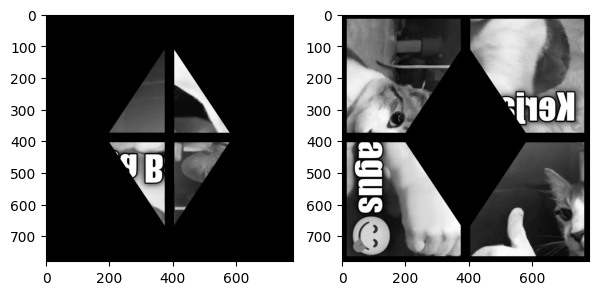

In [60]:
kicau1 = cv.imread('assets/citra1.PNG')
kicau2 = cv.imread('assets/citra2.PNG')

print(kicau1.shape)
print(kicau2.shape)

plt.figure(figsize = (7, 7))

plt.subplot(1, 2, 1)
plt.imshow(kicau1)

plt.subplot(1, 2, 2)
plt.imshow(kicau2)

#### Membaca Gambar kemudian Menampilkannya

Membaca citra dengan menggunakan `cv.imread` kemudian menampilkannya menggunakan `plt.imshow`.

(780, 780)
(780, 780)


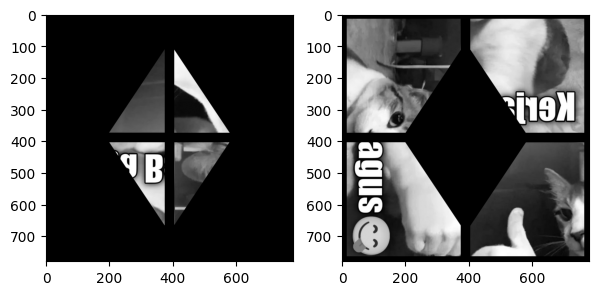

In [61]:
gray_kicau1 = cv.cvtColor(kicau1, cv.COLOR_BGR2GRAY)
gray_kicau2 = cv.cvtColor(kicau2, cv.COLOR_BGR2GRAY)

plt.figure(figsize = (7, 7))

plt.subplot(1, 2, 1)
plt.imshow(gray_kicau1, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(gray_kicau2, cmap = 'gray')

print(gray_kicau1.shape)
print(gray_kicau2.shape)

#### Mengubah Citra menjadi Grayscale kemudian Menampilkannya

Mengubah citra ke grayscale dengan menggunakan `cv.cvtColor(, cv.COLOR_BGR2GRAY)` kemudian menampilkannya menggunakan `plt.imshow`

In [62]:
def rotate(image, val): 
    h = image.shape[0]
    w = image.shape[1] 
    val = int(val) % 360  
    if val == 0: return image 
    elif val == 90: 
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[j, h - 1 - i] = image[i, j] 
        return rot 
    elif val == 180: 
        rot = np.zeros_like(image, dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j] 
        return rot 
    elif val == 270:  
        rot = np.zeros((w, h), dtype=image.dtype) 
        for i in range(h): 
            for j in range(w): rot[w - 1 - j, i] = image[i, j] 
        return rot 
    return image 

### Fungsi Rotasi (90, 180, 270)

Fungsi tersebut digunakan untuk rotasi citra sebesar `90, 180, dan 270 derajat`, yang di mana fungsi tersebut `mengecek` terlebih dahulu derajat yang dimasukkan dan `memoduluskannya` dengan `360` untuk `menormalisasi sudutnya` agar tidak `melebihi 360 derajat`, kemudian tergantung besar sudut yang di masukkan operasinya akan berbeda. Jika memasukkan `90`, maka citra akan masuk ke operasi `rotasi 90` yang akan `mentranspose matriks` kemudian `membalikkan indexing baris matriks` menjadi `berlawanan arah`, jika memasukkan `180`, maka akan masuk ke operasi `rotasi 180` yang akan `membalik indexing baris dan kolom matriks`, dan jika memasukkan `270`, maka akan masuk ke `operasi 270` yang akan `mentranspose matriks` kemudian `membalik indexing kolom matriks`.

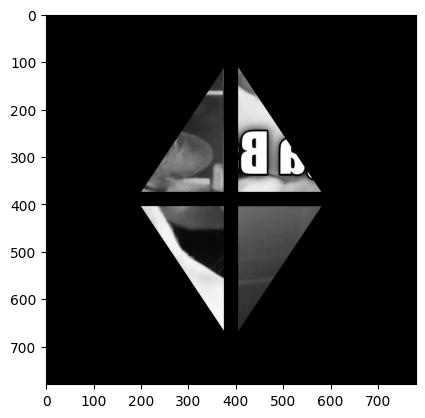

In [63]:
kicau_1r = rotate(gray_kicau1, val = 180)

plt.imshow(kicau_1r, cmap = 'gray')
plt.show()

#### Merotasi Citra dengan Fungsi Rotasi dengan Derajat 90 kemudian Menampilkannya



In [64]:
def gabung(image1, image2):
    merged = image1 + image2;
    return merged;

#### Fungsi Penjumlahan Citra

Fungsi ini digunakan untuk menempatkan sebuah `citra di atas citra lainnya`, hal itu dapat dilakukan dengan `menjumlahkan kedua matriks citra`.

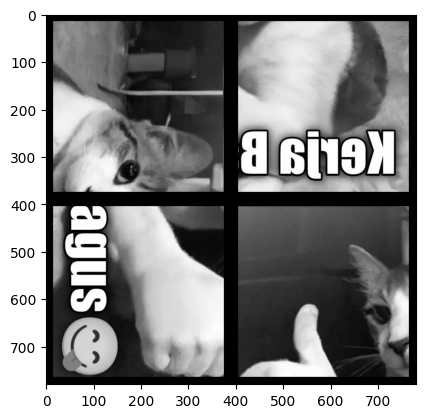

In [65]:
kicau_gabung = gabung(kicau_1r, gray_kicau2)

plt.imshow(kicau_gabung, cmap = 'gray')

#### Menempatkan Citra Kicau1 yang Sudah Dirotasi di atas Citra Kicau2 kemudian Menampilkannya

In [66]:
def potong(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

#### Fungsi Slilcing Citra

Fungsi ini digunakan untuk `memotong sebuah citra`. Pada fungsi tersebut terdapat `2 mode` yaitu memotong citra pada sumbu `horizontal` dan memotong citra pada sumbu `vertikal` yang ditentukan oleh `paramater ke empat` fungsi. Memotong pada sumbu `horizontal` dapat dilakukan dengan cara mengambil `semua kolom` dan mengambil `baris pada interval tertentu`, sedangkan untuk memotong pada sumbu `vertikal` dapat dilakukan dengan cara mengambil `semua baris` dan mengambil `kolom pada interval tertentu`.

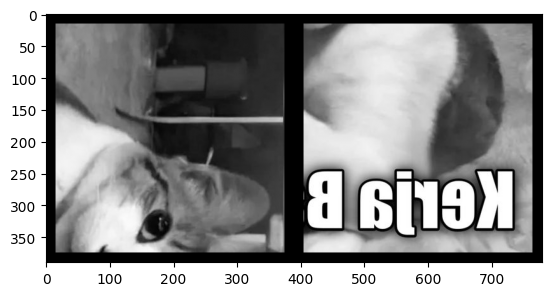

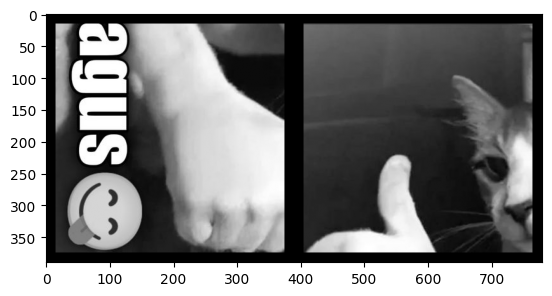

In [67]:
kicau_potong1 = potong(kicau_gabung, 0, 390, mode='H')
kicau_potong2 = potong(kicau_gabung, 390, 780, mode='H')

plt.imshow(kicau_potong1, cmap = 'gray')
plt.show()

plt.imshow(kicau_potong2, cmap = 'gray')
plt.show()

#### Memotong Citra pada sumbu Horizontal dan Membuat Citra terbagi menjadi 2 Bagian dengan `Fungsi Pootong` kemudian Menampilkannya

Text(0.5, 1.0, 'Citra 4')

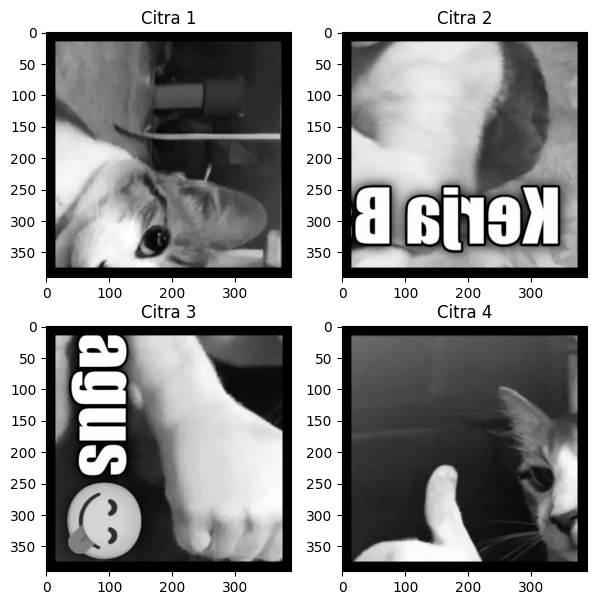

In [68]:
kicau_potong1_v1 = potong(kicau_potong1, 0, 390, mode='V')
kicau_potong1_v2 = potong(kicau_potong1, 390, 780, mode='V')
kicau_potong2_v1 = potong(kicau_potong2, 0, 390, mode='V')
kicau_potong2_v2 = potong(kicau_potong2, 390, 780, mode='V')

plt.figure(figsize=(7,7))

plt.subplot(2, 2, 1)
plt.imshow(kicau_potong1_v1, cmap = 'gray')
plt.title('Citra 1')

plt.subplot(2, 2, 2)
plt.imshow(kicau_potong1_v2, cmap = 'gray')
plt.title('Citra 2')

plt.subplot(2, 2, 3)
plt.imshow(kicau_potong2_v1, cmap = 'gray')
plt.title('Citra 3')

plt.subplot(2, 2, 4)
plt.imshow(kicau_potong2_v2, cmap = 'gray')
plt.title('Citra 4')


#### Memotong 2 Buah Citra Sebelumnya menjadi 2 Bagian lagi pada Sumbu Vertikal, Sehingga 1 Citra Awal menjadi 4 Bagian Citra yang Tersendiri dengan `Fungsi Potong` kemudian Menampilkannya

In [69]:
def flip(image, mode='X'): 
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype) 
    for i in range(h): 
        for j in range(w): 
            if mode == 'X': 
                hasil[i, j] = image[i, w - 1 - j] 
            elif mode == 'Y': 
                hasil[i, j] = image[h - 1 - i, j] 
    return hasil

#### Fungsi Refleksi Citra sesuai Sumbu

Fungsi ini digunakan untuk `merefleksikan citra` terhadap `sumbu tertentu`, seperti terhadap sumbu `horizontal` atau terhadap sumbu `vertikal`. Jika terhadap `horizontal`, maka `indexing kolom matriksnya` akan `dimulai berlawanan arah` dari yang seharusnya, sedangkan jika terhadap sumbu `vertikal` maka `indexing baris matriksnya` yang akan `dimulai berlawanan arah` dari yang seharusnya.

Text(0.5, 1.0, 'Citra 4')

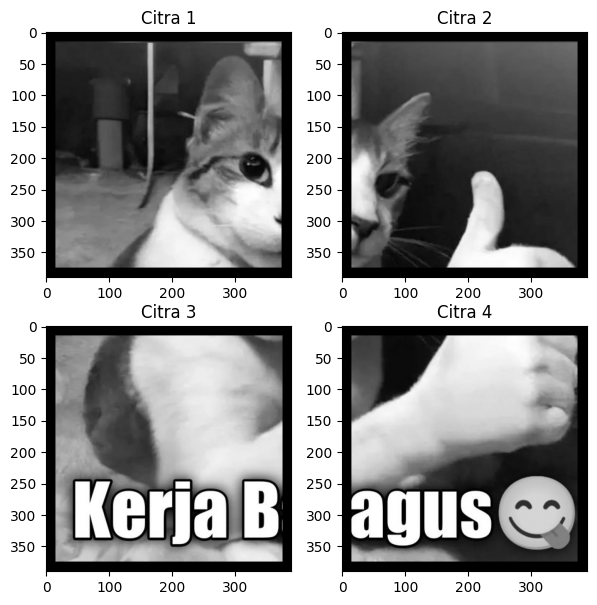

In [70]:
kicau_1 = rotate(kicau_potong1_v1, 270)
kicau_2 = flip(kicau_potong1_v2, mode='X')
kicau_3 = rotate(kicau_potong2_v1, 270)
kicau_4 = flip(kicau_potong2_v2, mode='X')

plt.figure(figsize=(7,7))

plt.subplot(2, 2, 1)
plt.imshow(kicau_1, cmap = 'gray')
plt.title('Citra 1')

plt.subplot(2, 2, 2)
plt.imshow(kicau_4, cmap = 'gray')
plt.title('Citra 2')

plt.subplot(2, 2, 3)
plt.imshow(kicau_2, cmap = 'gray')
plt.title('Citra 3')

plt.subplot(2, 2, 4)
plt.imshow(kicau_3, cmap = 'gray')
plt.title('Citra 4')


#### Merotasi dan Mereflekasi Citra menggunakan `Fungsi Rotasi` dan `Fungsi Flip` kemudian Menampilkannya

- Variabel `Kicau_1 dirotasi 270 derajat` kemudian ditampilkan pada `urutan pertama`
- Variabel `Kicau_2 direfleksi` terhadap sumbu `horizontal` kemudian ditampilkan pada `urutan ketiga`
- variabel `Kicau_3 dirotasi 270 derajat` kemudian ditampilkan pada `urutan keempat`
- Variabel `Kicau_4 direfleksi` terhadap sumbu `horizontal` kemudian ditampilkan pada `urutan kedua`



In [71]:
def translasi(image, geser_x=0, geser_y=0): 
    image = np.array(image) 
    h, w = image.shape 
    hasil = np.zeros((h, w), dtype=image.dtype) 
    
    for i in range(h): 
        for j in range(w): 
            new_i = i + geser_y 
            new_j = j + geser_x 
            if 0 <= new_i < h and 0 <= new_j < w: 
                hasil[new_i, new_j] = image[i, j] 
    return hasil 

#### Fungsi Geser Citra

Fungsi ini digunakan untuk `menggeser citra` ke `sumbu x` dan `sumbu y` tertentu, hal ini dapat dilakukan dengan cara `baris` matriks citra `dijumlahkan` dengan `besaran geser` pada `sumbu x` dan `kolom` matriks citra `dijumlahkan` dengan `besaran geser` pada `sumbu y`

dsdsd

Text(0.5, 1.0, 'Citra 4')

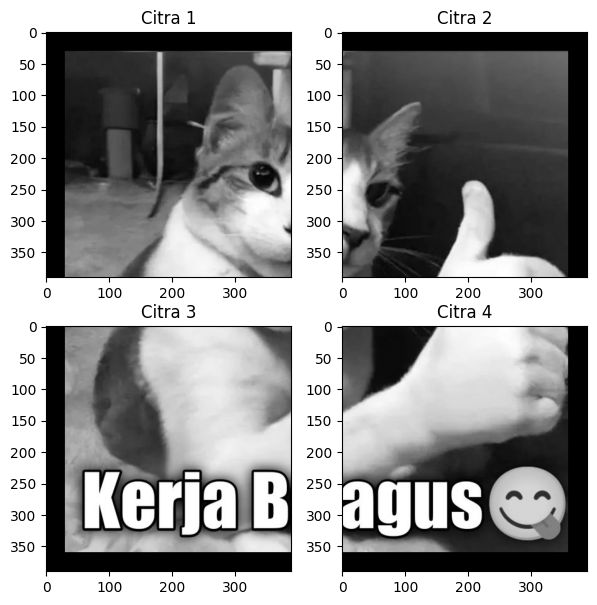

In [72]:
trans1 = translasi(kicau_1, geser_x = 15, geser_y = 15)
trans2 = translasi(kicau_4, geser_x = -15, geser_y = 15)
trans3 = translasi(kicau_2, geser_x = 15, geser_y = -15)
trans4 = translasi(kicau_3, geser_x = -15, geser_y = -15)

plt.figure(figsize=(7,7))

plt.subplot(2, 2, 1)
plt.imshow(trans1, cmap = 'gray')
plt.title('Citra 1')

plt.subplot(2, 2, 2)
plt.imshow(trans2, cmap = 'gray')
plt.title('Citra 2')

plt.subplot(2, 2, 3)
plt.imshow(trans3, cmap = 'gray')
plt.title('Citra 3')

plt.subplot(2, 2, 4)
plt.imshow(trans4, cmap = 'gray')
plt.title('Citra 4')

#### Menggeser Keempat Variabel Citra sesuai Angka dengan Menggunakan `Fungsi Translasi` dan Menampungnya dalam Variabel Bernama Trans Tertentu Kemudian Menampilkannya

Di sini saya menggesernya sejauh:
- `Kicau_1` ditampung dalam `trans1` dan `digeser` sejauh `15 piksel` pada `sumbu x` dan sejauh `15 piksel` pada `sumbu y`
- `Kicau_4` ditampung dalam `trans2` dan `digeser` sejauh `-15 piksel` pada `sumbu x` dan sejauh `15 piksel` pada `sumbu y`
- `Kicau_2` ditampung dalam `trans3` dan `digeser` sejauh `15 piksel` pada `sumbu x` dan sejauh `-15 piksel` pada `sumbu y`
- `Kicau_3` ditampung dalam `trans4` dan `digeser` sejauh `-15 piksel` pada `sumbu x` dan sejauh `-15 piksel` pada `sumbu y`

In [73]:

def dilatasi(image, p1=0, p2=0, p3=0, p4=0): 
    h, w = image.shape 
    dilated = np.zeros((h * 2, w * 2)).astype(int) 
    for y in range(h * 2): 
        for x in range(w * 2): 
            dilated[y][x] = image[int(y / 2)][int(x / 2)] 
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2) 
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4) 
    return dilated[sy:ey, sx:ex] 

#### Fungsi Memperbesar Citra Kemudian Memotong Bagian Tepi Citra sesuai Parameter

Fungsi ini digunakan untuk `memperbesar` sebuah citra kemudian `memotong` bagian `tepi citranya`. Di sini saya melakukannya dengan cara `mengalikan tinggi dan lebar` citra dengan `skala 2` atau `2x lipat ukuran semula`, kemudian `mengisi pixel` dengan `koordinat dibagi 2`, kemudian `menguranginya` seusai dengan `parameter` yang diinputkan

Text(0.5, 1.0, 'Citra 4')

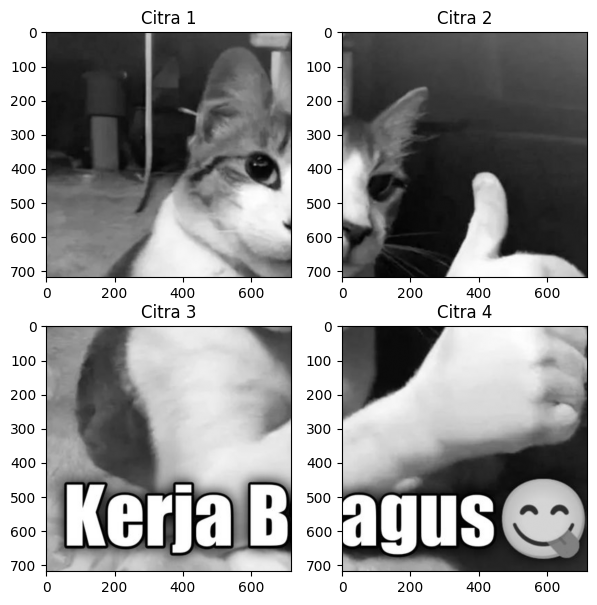

In [74]:
dil1 = dilatasi(trans1, 62, 0, 62, 0)
dil2 = dilatasi(trans2, 62, 0, 0, 62)
dil3 = dilatasi(trans3, 0, 62, 62, 0)
dil4 = dilatasi(trans4, 0, 62, 0, 62)

plt.figure(figsize=(7,7))

plt.subplot(2, 2, 1)
plt.imshow(dil1, cmap = 'gray')
plt.title('Citra 1')

plt.subplot(2, 2, 2)
plt.imshow(dil2, cmap = 'gray')
plt.title('Citra 2')

plt.subplot(2, 2, 3)
plt.imshow(dil3, cmap = 'gray')
plt.title('Citra 3')

plt.subplot(2, 2, 4)
plt.imshow(dil4, cmap = 'gray')
plt.title('Citra 4')

#### Memperbesar Citra dengan Menggunakan `Fungsi dilatasi` dan kemudian Memotong Tepinya dengan Besaran 62 dengan Menggunakan `Fungsi Dilatasi` juga kemudian Menampilkannya

Kenapa saya menggunakan `besaran 62` untuk memotong tepinya? Hal ini saya lakukan karena saya merasa `angka tersebut` lah yang `cocok` dan `pas` digunakan untuk `memotong tepi citra`

In [75]:
def merge_hori(image1, image2):
    image1 = np.array(image1)
    image2 = np.array(image2)

    tinggi = max(image1.shape[0], image2.shape[0])
    lebar = image1.shape[1] + image2.shape[1]
    
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil [0:image1.shape[0], 0:image1.shape[1]] = image1
    hasil [0:image2.shape[0], image1.shape[1]:] = image2
    
    return hasil;

def merge_verti(image1, image2):
    image1 = np.array(image1)
    image2 = np.array(image2)

    tinggi = image1.shape[0] + image2.shape[0]
    lebar = max(image1.shape[1], image2.shape[1])
    
    hasil = np.zeros((tinggi, lebar)).astype(int)
    hasil [0:image1.shape[0], 0:image1.shape[1]] = image1
    hasil [image1.shape[0]:, 0:image2.shape[1]] = image2
    
    return hasil;

#### Fungsi Menggabungkan Dua Citra Secara Horizontal dan Vertikal

Fungsi ini digunakan untuk `menggabungkan dua buah citra menjadi satu`. Terdapat dua mode penggabungan yaitu `horizontal dan vertikal`. Untuk penggabungan `horizontal`, saya melakukannya dengan cara menentukan `tinggi kanvas` sebesar `nilai maksimum tinggi kedua citra` agar muat menampung `keduanya`, dan `lebar kanvas` sebagai `jumlah lebar` kedua citra karena gambar `berjejer ke samping`. Kemudian `image1 diletakkan di sisi kiri kanvas`, dan `image2 diletakkan tepat di sebelah kanannya mulai dari kolom sebesar lebar image1`. Untuk penggabungan `vertikal`, saya melakukannya dengan cara menentukan `tinggi kanvas` sebagai `jumlah tinggi kedua citra` karena `gambar bertumpuk ke bawah`, dan `lebar kanvas sebesar nilai maksimum lebar kedua citra` agar muat menampung keduanya. Kemudian `image1 diletakkan di bagian atas kanvas`, dan `image2 diletakkan tepat di bawahnya mulai dari baris sebesar tinggi image1`.

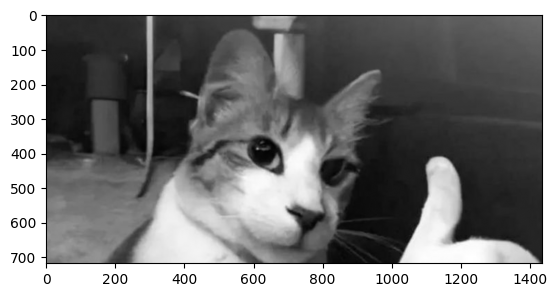

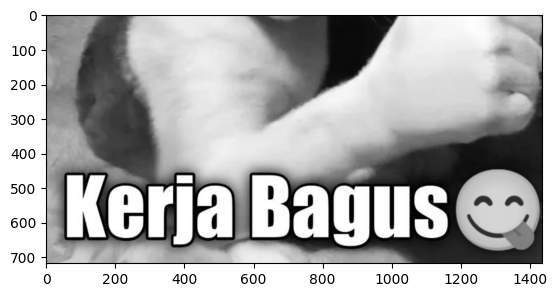

In [76]:
merge_atas = merge_hori(dil1, dil2)
merge_bawah = merge_hori(dil3, dil4)

plt.imshow(merge_atas, cmap='gray')
plt.show()

plt.imshow(merge_bawah, cmap='gray')
plt.show()

#### Menggabungkan 2 Citra Menjadi Atas dan Bawah kemudian Menampilkannya

- Untuk bagian atas, saya menggabungkan `citra dil1 dan dil2` dengan menggunakan `fungsi merge_hori` kemudian menampungnya dalam variabel `merge_atas`
- Untuk bagian bawah, saya menggabungkan `citra dil3 dan dil4` dengan menggunakan `fungsi merge_hori` kemudian menampungnya dalam variabel `merge_bawah`

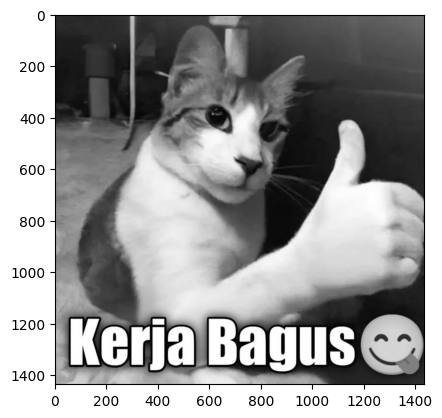

In [77]:
kicau_merge = merge_verti(merge_atas, merge_bawah)

plt.imshow(kicau_merge, cmap = 'gray')
plt.show()

#### Menggabungkan Citra Atas dan Bawah kemudian Menampilkannya

Menggabungkan citra pada variabel `merge_atas` dan `merge_bawah`

In [78]:
def tampilkan_histogram(citra, warna = "black"):
    histogram = np.zeros(256, dtype=int)

    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            nilai = int(citra[i, j])
            histogram[nilai] += 1
            
    plt.bar(range(256), histogram, width = 1, color = warna)
    plt.grid(True)

def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

#### Fungsi Menampilkan Histogram dan Normalisasi Citra

Fungsi tampilkan histogram digunakan untuk `menghitung dan menampilkan distribusi intensitas piksel` sebuah citra dalam bentuk `bar chart`. Saya melakukannya dengan cara membuat `array histogram berisi 256 elemen bernilai nol`, kemudian `menelusuri setiap piksel citra` dan `menambahkan cacahan` pada `index histogram` sesuai `nilai intensitas piksel` tersebut. Hasilnya kemudian `ditampilkan` menggunakan `bar chart` dengan `rentang nilai intensitas 0–255`.

Fungsi normalisasi digunakan untuk `merentangkan distribusi intensitas citra` agar memenuhi `range 0–255` secara penuh. Saya melakukannya dengan cara `mencari nilai intensitas minimum dan maksimum` dari citra, kemudian setiap `piksel dihitung ulang` menggunakan `rumus min-max` yaitu `nilai piksel dikurangi minimum` lalu `dibagi selisih maksimum dan minimum`, kemudian dikalikan `255`. Dengan begitu `piksel yang sebelumnya bernilai minimum akan menjadi 0`, dan `piksel yang bernilai maksimum akan menjadi 255`, sehingga histogram yang tadinya `sempit` akan `melebar memenuhi seluruh range intensitas`.

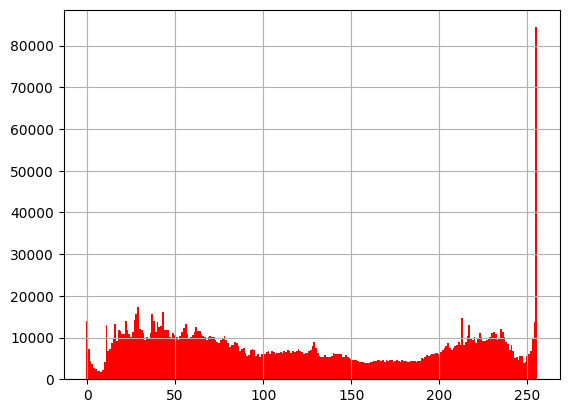

In [79]:
histogram = tampilkan_histogram(kicau_merge, 'red')

#### Menampilkan Histogram dari Hasil Merge menggunakan `Fungsi tampilkan_histogram`

In [80]:
def bagi(image1):
    return image1 // 2

#### Fungsi untuk membagi matriks dengan 2

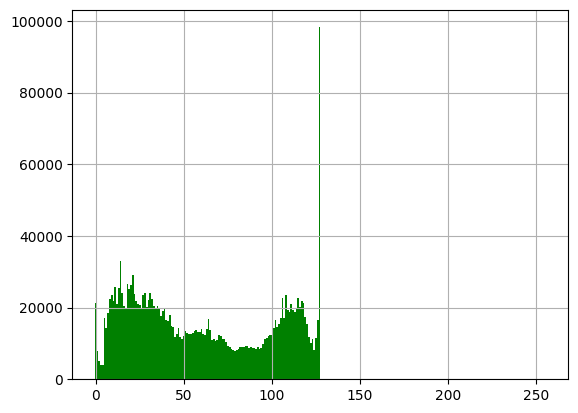

In [81]:
kicau_bagi = bagi(kicau_merge)

histo_kicau_bagi = tampilkan_histogram(kicau_bagi, 'green')

#### Membagi matriks dengan skala 2 dengan `Fungsi Bagi` kemudian Menampilkan Histogramnya

0 127
0 255


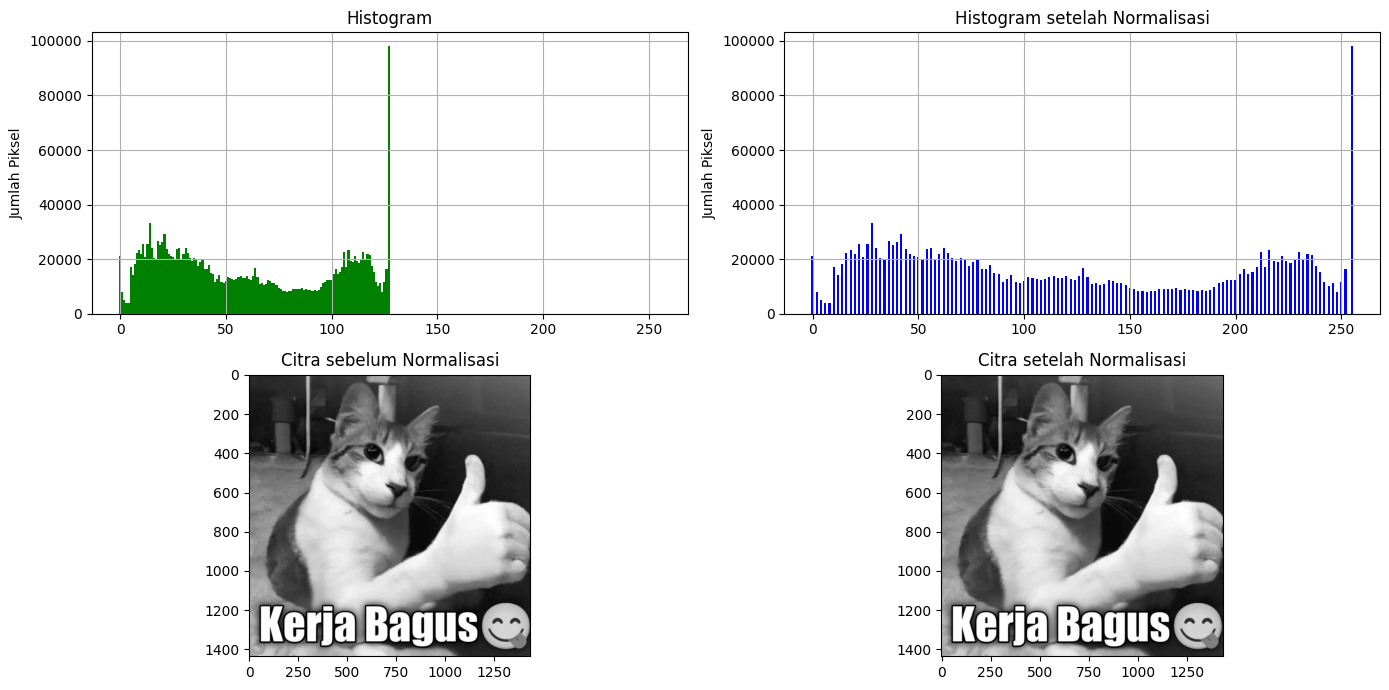

In [82]:
kicau_normal = normalisasi(kicau_bagi)

print(kicau_bagi.min(), kicau_bagi.max())
print(kicau_normal.min(), kicau_normal.max())

plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
plt.title('Histogram')
plt.ylabel('Jumlah Piksel')
histo_kicau_bagi = tampilkan_histogram(kicau_bagi, warna = 'green')

plt.subplot(2, 2, 2)
plt.title('Histogram setelah Normalisasi')
plt.ylabel('Jumlah Piksel')
histo_kicau_normal = tampilkan_histogram(kicau_normal, warna = 'blue')

plt.subplot(2, 2, 3)
plt.title('Citra sebelum Normalisasi')
plt.imshow(kicau_bagi, cmap = 'gray')

plt.subplot(2, 2, 4)
plt.title('Citra setelah Normalisasi')
plt.imshow(kicau_normal, cmap = 'gray')

plt.tight_layout()
plt.show()

#### Menormalisasi Citra agar Sebarannya Merata dalam Interval 0 - 255 menggunakan `Fungsi Normalisasi` kemudian Menampilkan Histogram Sebelum dan Sesudah Normalisasi

Berdasarkan perbadingan histogram di atas, dapat dilihat kalau `sebelum normalisasi` distribusi pikselnya hanya ada di `interval 0–130` yang menunjukkan bahwa sebagian besar piksel memiliki `intensitas rendah `hingga menengah sehingga citra terlihat `gelap` dan memiliki `kontras yang rendah`. `Setelah dilakukan normalisasi`, distribusi piksel menyebar ke seluruh `interval 0–255`. Hal ini terjadi karena `normalisasi min-max merentangkan nilai piksel` yang sebelumnya maksimum di sekitar `130` menjadi `255`, dan `nilai minimumnya` tetap di `0`, sehingga `seluruh nilai di antaranya ikut direntangkan`, sehingga `kecerahan citra meningkat` dan `kontrasnya juga ikut meningkat`. Hal ini menunjukkan bahwa `normalisasi berpengaruh` untuk `meningkatkan kecerahan dan kontras` citra karena `normalisasi min-max` dapat merentangkan dan mendistribusikan piksel merata dalam `interval 0 - 255`.

In [83]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10,  4/10,  4/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

def zero_padding(citra, pad):
    height, width = citra.shape
    citra_pad = np.zeros((height + 2*pad, width + 2*pad), dtype=citra.dtype)
    citra_pad[pad:pad+height, pad:pad+width] = citra
    return citra_pad

def konvolusi(citra, kernel):
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    citra_pad = zero_padding(citra, max(pad_h, pad_w))
    h, w = citra.shape
    hasil = np.zeros((h, w), dtype=np.float64)

    for i in range(h):
        for j in range(w):
            region = citra_pad[i:i+kh, j:j+kw]
            hasil[i, j] = np.sum(region * kernel)

    return hasil

#### Inisialisasi Kernel, Fungsi Zero Padding, dan Fungsi Konvolusi

- Inisialisasi Kernel dengan kernel yang telah disediakan di soal
- Fungsi Zero Padding digunakan untuk `menambahkan border berisi nilai 0` di `sekeliling citra` agar `hasil konvolusinya bisa tetap sesuai dengan ukuran asli citranya`
- Fungsi Konvolusi digunakan untuk `memproses citra menggunakan kernel yang telah disediakan`. Hal ini dapat dilakukan dengan `menentukan ukuran padding`, kemudian `menerapkan zero padding` agar ukuran output konvolusi sama dengan input. Setelah menerapkan `zero padding`, setiap piksel pada citra `ditelusuri satu per satu`, lalu `dikalikan dengan elemen per elemen dengan kernel` dan `dijumlahkan seluruhnya` untuk menghasilkan `nilai piksel baru`.

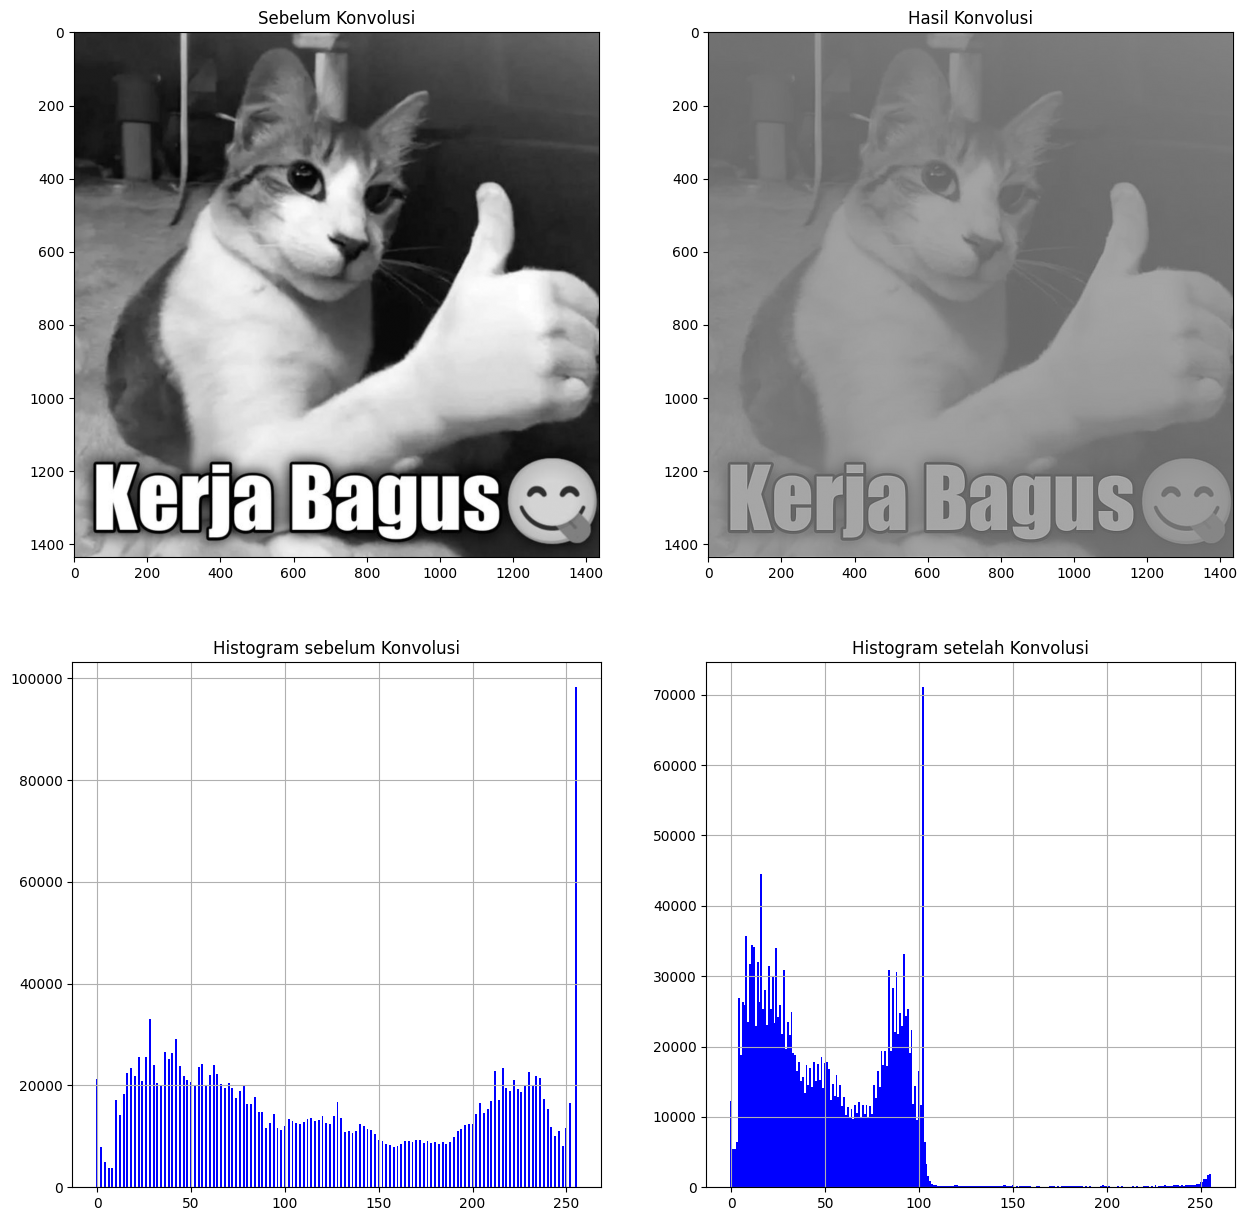

In [84]:
kicau_konvo = konvolusi(kicau_normal, kernel)

plt.figure(figsize=(15, 15))

plt.subplot(2, 2, 1)
plt.title('Sebelum Konvolusi')
plt.imshow(kicau_normal, cmap = 'gray')

plt.subplot(2, 2, 2)
plt.title('Hasil Konvolusi')
plt.imshow(kicau_konvo, cmap = 'gray')

plt.subplot(2, 2, 3)
plt.title('Histogram sebelum Konvolusi')
histo_kicau_normal = tampilkan_histogram(kicau_normal, warna = 'blue')

plt.subplot(2, 2, 4)
plt.title('Histogram setelah Konvolusi')
histo_kicau_konvo = tampilkan_histogram(kicau_konvo, warna = 'blue')


#### Analisis Perubahan Sebelum dan Sesudah Konvolusi

- ##### Secara Visual
Secara visual, citra `sesudah konvolusi` terlihat `lebih abu-abu` dan `flat` dibanding `sebelumnya`. Hal ini sesuai dengan cara kerja kernel yang digunakan, yang di mana `area yang seragam (flat) menghasilkan nilai mendekati nilai tengah (abu-abu)`, sementara `area tepi objek` seperti batas rambut kucing, jari, dan teks "Kerja Bagus" masih terlihat namun dengan `kontras yang berbeda`. Teks yang sebelumnya `putih tebal` menjadi `lebih redup` karena `nilai pikselnya tertarik ke tengah range` oleh `operasi konvolusi`.
- ##### Secara Nilai Piksel
`Sebelum konvolusi`, nilai piksel tersebar dari `0–255` dengan spike besar di nilai `255` yang merepresentasikan `piksel putih` dari `teks` dan `area terang`. `Sesudah konvolusi`, spike di nilai `255 menghilang` dan distribusi `bergeser` ke `range 0–150`, menandakan bahwa `nilai piksel ekstrem (sangat terang/gelap) sudah tidak dominan lagi` karena `kernel meratakan perbedaan intensitas di sekitar tiap piksel`.
- ##### Berdasarkan Histogram
Histogram `sebelum konvolusi` memiliki spike sangat besar di `nilai 255` dan distribusi yang menyebar di `0–255`. `Sesudah konvolusi`, spike tersebut `hilang` dan distribusi `terkonsentrasi di range 0–150` dengan puncak di sekitar `nilai 50–100`. Ini menunjukkan bahwa `konvolusi dengan kernel` yang digunakan `menurunkan rata-rata intensitas citra` secara keseluruhan dan `menghilangkan nilai-nilai ekstrem`, sehingga `citra terlihat lebih abu-abu` dan `kurang kontras dibanding aslinya`.

=== Sebelum Konvolusi ===
Min  : 0
Max  : 255
Mean : 123.20
=== Sesudah Konvolusi ===
Min  : -167.70000000000002
Max  : 247.39999999999998
Mean : 49.36


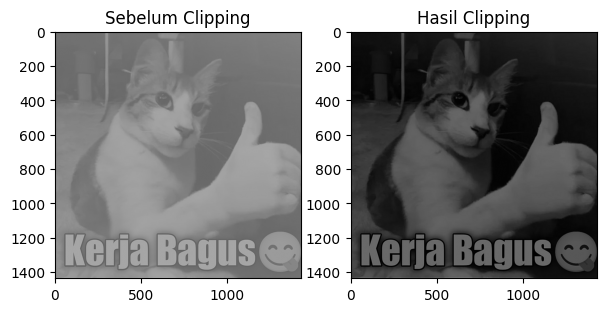

In [85]:
def clipping(citra):
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            val = citra[i, j]
            hasil[i, j] = 255 if val > 255 else (0 if val < 0 else int(val))
    return hasil
    

kicau_clipping = clipping(kicau_konvo)

plt.figure(figsize=(7, 7))

plt.subplot(1, 2, 1)
plt.title('Sebelum Clipping')
plt.imshow(kicau_konvo, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.title('Hasil Clipping')
plt.imshow(kicau_clipping, cmap = 'gray')

print("=== Sebelum Konvolusi ===")
print(f"Min  : {kicau_normal.min()}")
print(f"Max  : {kicau_normal.max()}")
print(f"Mean : {kicau_normal.mean():.2f}")

print("=== Sesudah Konvolusi ===")
print(f"Min  : {kicau_konvo.min()}")
print(f"Max  : {kicau_konvo.max()}")
print(f"Mean : {kicau_konvo.mean():.2f}")

#### Fungsi Clipping

Fungsi clipping digunakan untuk `mengubah nilai piksel` yang `keluar dari rentang interval citra (0 - 255)`. Jika nilai piksel ada yang `< 0`, maka akan `diubah menjadi 0`, kemudian jika ada nilai yang `> 255`, maka akan `diubah menjadi 255`.

#### Analisis Nilai Piksel dan Clipping
- ##### Perubahan Nilai Piksel
`Sebelum konvolusi`, nilai piksel berada pada `range 0.0 – 255.0` dengan `rata-rata 123.63`, yang menandakan distribusi intensitas citra `cukup seimbang` antara piksel `gelap` dan `terang`. `Setelah konvolusi`, nilai piksel berubah drastis menjadi `-168.26 hingga 248.37` dengan rata-rata turun ke `49.54`. Hal ini membuktikan bahwa `konvolusi menghasilkan nilai negatif` yang tidak valid untuk ditampilkan sebagai citra, sekaligus menjelaskan mengapa `rata-rata intensitas turun drastis`, karena `kernel` yang digunakan `memiliki total bobot negatif` sehingga `menekan nilai piksel secara keseluruhan`.
- ##### Perlunya Clipping
Karena terdapat `nilai negatif (min: -168.26)` yang tidak bisa `direpresentasikan sebagai piksel`, maka `clipping diperlukan` untuk `memotong nilai-nilai tersebut` kembali ke `range valid 0–255`. Nilai `di bawah 0` diset menjadi `0 (hitam)` dan nilai `di atas 255` diset menjadi `255 (putih)`.
- ##### Hasil Clipping
`Setelah clipping`, citra kembali dapat ditampilkan dengan `normal`. Secara visual `citra terlihat lebih gelap` dibanding `aslinya` karena `rata-rata intensitas yang turun` dari `123.63` menjadi `49.54`, namun `detail objek` seperti kucing, jari, dan teks "Kerja Bagus" `masih terlihat dengan baik` karena `tepi-tepi objek` tetap `dipertahankan` oleh `operasi konvolusi`.

=== Sebelum Konvolusi ===
Min  : -167.70000000000002
Max  : 247.39999999999998
Mean : 49.36
=== Sesudah Konvolusi ===
Min  : 0
Max  : 247
Mean : 49.20


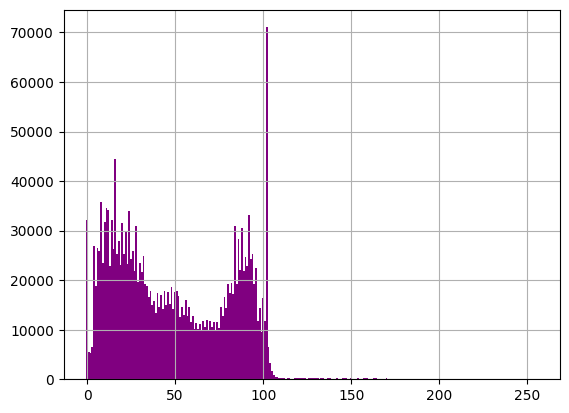

In [86]:
histo_kicau_clipping = tampilkan_histogram(kicau_clipping, warna = 'purple')

print("=== Sebelum Konvolusi ===")
print(f"Min  : {kicau_konvo.min()}")
print(f"Max  : {kicau_konvo.max()}")
print(f"Mean : {kicau_konvo.mean():.2f}")

print("=== Sesudah Konvolusi ===")
print(f"Min  : {kicau_clipping.min()}")
print(f"Max  : {kicau_clipping.max()}")
print(f"Mean : {kicau_clipping.mean():.2f}")

#### Analisis Histogram Setelah Clipping
`Histogram setelah clipping` menunjukkan `distribusi piksel yang terkonsentrasi` di `range 0–110` dengan spike besar di sekitar `nilai 100–105`. Ini adalah `bukti` langsung dari `efek clipping` sehingga `semua nilai negatif hasil konvolusi` (yang sebelumnya mencapai `-168.26`) `dipotong menjadi 0`, namun karena `nilainya tersebar` dari `-168 hingga 0`, setelah `di-clip` semuanya `menumpuk membentuk spike di nilai-nilai rendah`. Dibanding `histogram sebelum konvolusi` yang `menyebar hingga 255`, `histogram setelah clipping` `konsisten dengan nilai maksimum` hasil `konvolusi` sebesar `248.37` yang setelah `di-clip` tetap `di bawah 255`. Hal ini menjelaskan mengapa citra `hasil clipping` terlihat `lebih gelap`, karena `hampir seluruh piksel berada di separuh bawah range intensitas (0–128)`, sehingga tidak ada area yang `benar-benar putih terang` seperti `citra aslinya`.

## KESIMPULAN

#### Berdasarkan seluruh proses pengolahan citra yang telah dilakukan, dapat disimpulkan bahwa setiap tahapan yang dilakukan memberikan perubahan yang berbeda terhadap kualitas citra, seperti pada proses awal, saat di baca citra masih memiliki 3 layer citra, kemudian dikonversi menjadi grayscale yang mengakibatkan citra berubah menjadi 1 layer, dibuktikan dengan print yang dilakukan pada masing-masing kode menggunakan `.shape`. Perubahan ke grayscale juga bertujuan agar proses-proses citra yang dilakukan setelahnya menjadi lebih mudah karena memproses 1 layer.

#### Pada proses-proses selanjutnya, seperti rotasi, penjumlahan citra, slicing, translasi, dilatasi, dan merge, menunjukkan bahwa citra dapat dimanipulasi entah itu untuk diputar, dijumlahkan, dipotong, digeser, diperbesar, dan digabungkan.

#### Pada proses tahap akhir seperti histogram, konvolusi, dan clipping, citra diolah untuk mengetahui jumlah frekuensi untuk setiap intensitas piksel dari 0 hingga 255, selain itu juga citra dapat dimanipulasi distribusi intensitasnya dengan dibagi atau dinormalisasi, walau tidak mengubah visual gambar. Kemudian konvolusi digunakan untuk merubah visual citra, pada kasus modul 1, citra berubah menjadi buram karena kernel yang digunakan. Sementara itu, clippping digunakan untuk membatasi rentang piksel agar tetap berada pada rentang yang seharusnya, yaitu 0 - 255, sehingga citra yang awalnya buram berubah menjadi lebih jelas dengan kontras yang lebih tegas.

#### Secara keseluruhan dapat disimpulkan bahwa, proses pengolahan citra tidak hanya berfungsi untuk memodifikasi tampilan visual, tetapi juga untuk mengatur distribusi data piksel sesuai kebutuhan analisis. Setiap metode yang digunakan memiliki peran dan dampak yang berbeda, mulai dari penyederhanaan data, manipulasi geometris, hingga pengolahan intensitas dan peningkatan fitur tertentu. Oleh karena itu, pemilihan metode pengolahan citra harus disesuaikan dengan tujuan yang ingin dicapai agar hasil yang diperoleh optimal.